##  **Détection DDoS : Un Système de Détection Multiclasse et Multidimensionnel avec Divers Modèles de Machine Learning**

---

###  **Aperçu du Projet**

Ce projet vise à construire un système capable de **détecter et classifier** les attaques **DDoS (Déni de Service Distribué)** en utilisant le jeu de données **CICDDoS2019**. L'objectif est de développer un modèle de **classification multiclasse** capable d'identifier différents types d'attaques DDoS à partir du trafic réseau normal. Le jeu de données comprend plusieurs types d'attaques ayant des caractéristiques de trafic réseau différentes, ce qui en fait un problème complexe pour la détection DDoS.

---

###  **Description du Jeu de Données**

Le jeu de données **CICDDoS2019**, fourni par l'Institut Canadien pour la Cybersécurité (CIC), contient des données de trafic réseau représentant plusieurs types d'attaques DDoS ainsi que du trafic bénin (non-attaque). Le jeu de données comporte plusieurs attributs comme la taille des paquets, les adresses IP source/destination et les types de protocoles. La variable cible est composée de différentes étiquettes d'attaques :

| Étiquette | Description |
|-----------|-------------|
| **Syn** | Attaque par inondation SYN |
| **Benign** | Trafic normal (non-attaque) |
| **Portmap** | Attaque DDoS basée sur Portmapper |
| **UDP** | Attaque par inondation UDP générique |
| **MSSQL** | Attaque DDoS spécifique à MSSQL |
| **NetBIOS** | Attaque DDoS liée à NetBIOS |
| **LDAP** | Attaque basée sur le protocole LDAP |

---

###  **Aperçu du Processus**

####  **Collecte et Prétraitement des Données**

1. **Collecte des Chemins des Données** :
   - Les chemins des ensembles d'entraînement et de test sont collectés en parcourant les dossiers.
   - On s'assure que seuls les ensembles de données avec des noms correspondants sont utilisés pour l'entraînement et le test.

2. **Traitement des Données** :
   - **Mappage des Colonnes** : On mappe les noms de colonnes entre les ensembles d'entraînement et de test pour garantir leur cohérence. Les noms de colonnes dans l'ensemble de test sont renommés pour correspondre à ceux de l'ensemble d'entraînement.
   - **Gestion des Valeurs Nulles et Doublons** : On vérifie les valeurs nulles ou les doublons. Aucune valeur nulle n'est trouvée et les doublons sont supprimés.
   - **Suppression des Colonnes à Valeur Unique** : Les colonnes avec une seule valeur unique sont supprimées car elles n'apportent pas d'information utile.
   - **Suppression des Colonnes Fortement Corrélées** : Les colonnes avec un coefficient de corrélation ≥ 0,8 sont supprimées pour réduire la multicolinéarité et améliorer les performances du modèle.

---

###  **Analyse Exploratoire des Données (EDA)**

Plusieurs visualisations clés ont été réalisées pour comprendre le jeu de données :


- **Distribution de la Durée des Flux** :
   - Analyse de la durée des flux pour le trafic DDoS et normal.
- **Longueur Moyenne des Paquets par Protocole et par Attaque** :
   - Exploration de la longueur moyenne des paquets par type de protocole et par type d'attaque.
- **Distribution des Flags par Type d'Attaque** :
   - Distribution des différents types de flags par type d'attaque.
- **Distribution des Demandes par Protocole** :
   - Nombre de requêtes provenant de différents protocoles.
- **Matrice de Corrélation** :
   - Heatmap pour visualiser la matrice de corrélation et identifier les relations entre les caractéristiques.

---

###  **Prétraitement des Données et Ingénierie des Caractéristiques**

- **Division Entraînement/Test** :
   - Le jeu de données est divisé en ensembles d'entraînement, de validation et de test pour assurer une évaluation correcte du modèle.
- **Encodage des Caractéristiques** :
   - La colonne cible est encodée à l'aide de **LabelEncoder** pour convertir les étiquettes catégorielles en valeurs numériques.
- **Mise à l'Échelle des Caractéristiques** :
   - On applique la **Normalisation Min-Max** pour mettre les caractéristiques à l'échelle, améliorant ainsi les performances des algorithmes basés sur la distance.

---

###  **Entraînement et Évaluation du Modèle**

- **Sélection du Modèle** :
   - Plusieurs modèles sont entraînés et évalués pour la classification multiclasse, notamment :
     - **Forêt Aléatoire (Random Forest)**
     - **Extra Trees Classifier**
     - **XGBoost**

- **Évaluation du Modèle** :
   - On évalue les modèles à l'aide de diverses métriques comme la **précision (accuracy)**, la **précision (precision)**, le **rappel (recall)**, le **score F1** et l'**AUC ROC**.
   - Les courbes ROC sont tracées pour comparer les performances de chaque modèle à travers les différentes classes.
   - Un tableau des scores des modèles est créé et affiché pour faciliter la comparaison.

---

###  **Visualisation des Résultats**

- **Comparaison des Modèles** :
   - On trace le **score de précision (accuracy)** pour chaque modèle afin de comparer visuellement leurs performances.
   - Les courbes ROC pour tous les modèles sont tracées pour analyser leur capacité de classification, en particulier pour les tâches de classification multiclasse.

---



## 📚 Importation des Bibliothèques 

In [ ]:
import os
from tqdm import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.figure as fig
import matplotlib.cm as cm
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score, roc_curve


from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

import pickle

import warnings
warnings.filterwarnings('ignore')
import os, gc, warnings
import pandas as pd
import numpy as np
warnings.filterwarnings('ignore')

In [2]:
import os
from tqdm import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.figure as fig
import matplotlib.cm as cm
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score, roc_curve


from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

import pickle

import warnings
warnings.filterwarnings('ignore')
import os, gc, warnings
import pandas as pd
import numpy as np
warnings.filterwarnings('ignore')

In [ ]:
QUOTA     = 50_000
EXCLURE   = ['WebDDoS']

def charger_fichier(chemin):
    benign, attaques, nb_b, nb_a = [], [], 0, 0

    for chunk in pd.read_csv(chemin, chunksize=50_000, low_memory=True,
                             on_bad_lines='skip', dtype={'SimillarHTTP': 'str'}):
        chunk.columns = chunk.columns.str.strip()
        if 'Label' not in chunk.columns: continue

        chunk = chunk[~chunk['Label'].isin(EXCLURE)]
        chunk = chunk.replace([np.inf, -np.inf], np.nan).dropna()
        if len(chunk) == 0: continue

        if nb_b < QUOTA:
            b = chunk[chunk['Label'] == 'BENIGN']
            n = min(QUOTA - nb_b, len(b))
            if n > 0: benign.append(b.sample(n=n, random_state=42)); nb_b += n

        if nb_a < QUOTA:
            a = chunk[chunk['Label'] != 'BENIGN']
            n = min(QUOTA - nb_a, len(a))
            if n > 0: attaques.append(a.sample(n=n, random_state=42)); nb_a += n

        if nb_b >= QUOTA and nb_a >= QUOTA: break

    if benign or attaques:
        df = pd.concat(benign + attaques, ignore_index=True)
        df = df.sample(frac=1, random_state=42).reset_index(drop=True)
        print(f"  {os.path.basename(chemin):<30} BENIGN:{nb_b:>6} | Attaque:{nb_a:>6} | Total:{len(df):>6}")
        return df
    return None

def charger_dossier(dossier):
    frames = []
    for _, _, filenames in os.walk(dossier):
        for f in sorted(filenames):
            
            if f.endswith('.csv'):
                df = charger_fichier(os.path.join(dossier, f))
                if df is not None: frames.append(df)
                gc.collect()
    df = pd.concat(frames, ignore_index=True).sample(frac=1, random_state=42).reset_index(drop=True)
    del frames; gc.collect()
    return df

# Chargement
print("TRAIN (01-12)"); df_train = charger_dossier('E:/01-12/')
print("TEST  (03-11)"); df_test  = charger_dossier('E:/03-11/')



TRAIN (01-12)
  DrDoS_DNS.csv                  BENIGN:  3354 | Attaque: 50000 | Total: 53354
  DrDoS_LDAP.csv                 BENIGN:  1592 | Attaque: 50000 | Total: 51592
  DrDoS_MSSQL.csv                BENIGN:  1986 | Attaque: 50000 | Total: 51986
  DrDoS_NTP.csv                  BENIGN: 14271 | Attaque: 50000 | Total: 64271
  DrDoS_NetBIOS.csv              BENIGN:  1687 | Attaque: 50000 | Total: 51687
  DrDoS_SNMP.csv                 BENIGN:  1493 | Attaque: 50000 | Total: 51493
  DrDoS_SSDP.csv                 BENIGN:   755 | Attaque: 50000 | Total: 50755
  DrDoS_UDP.csv                  BENIGN:  2127 | Attaque: 50000 | Total: 52127
  Syn.csv                        BENIGN:   381 | Attaque: 50000 | Total: 50381
  TFTP.csv                       BENIGN: 25095 | Attaque: 50000 | Total: 75095
  UDPLag.csv                     BENIGN:  3684 | Attaque: 50000 | Total: 53684
TEST  (03-11)
  LDAP.csv                       BENIGN:  5053 | Attaque: 50000 | Total: 55053
  MSSQL.csv             

# Enrigistrer en  fichier csv 

In [ ]:
#df_train.to_csv('E:/data/df_train.csv', index=False)
#df_test.to_csv('E:/data/df_test.csv', index=False)

# Chargement des fichiers

In [92]:
train_df= pd.read_csv('C:/Users/fatou/Downloads/data_train.csv')
test_df = pd.read_csv('C:/Users/fatou/Downloads/data_test.csv')

In [ ]:
#train_df= pd.read_csv('E:/data/df_entrainement.csv')
#test_df = pd.read_csv('E:/data/df_teste.csv')

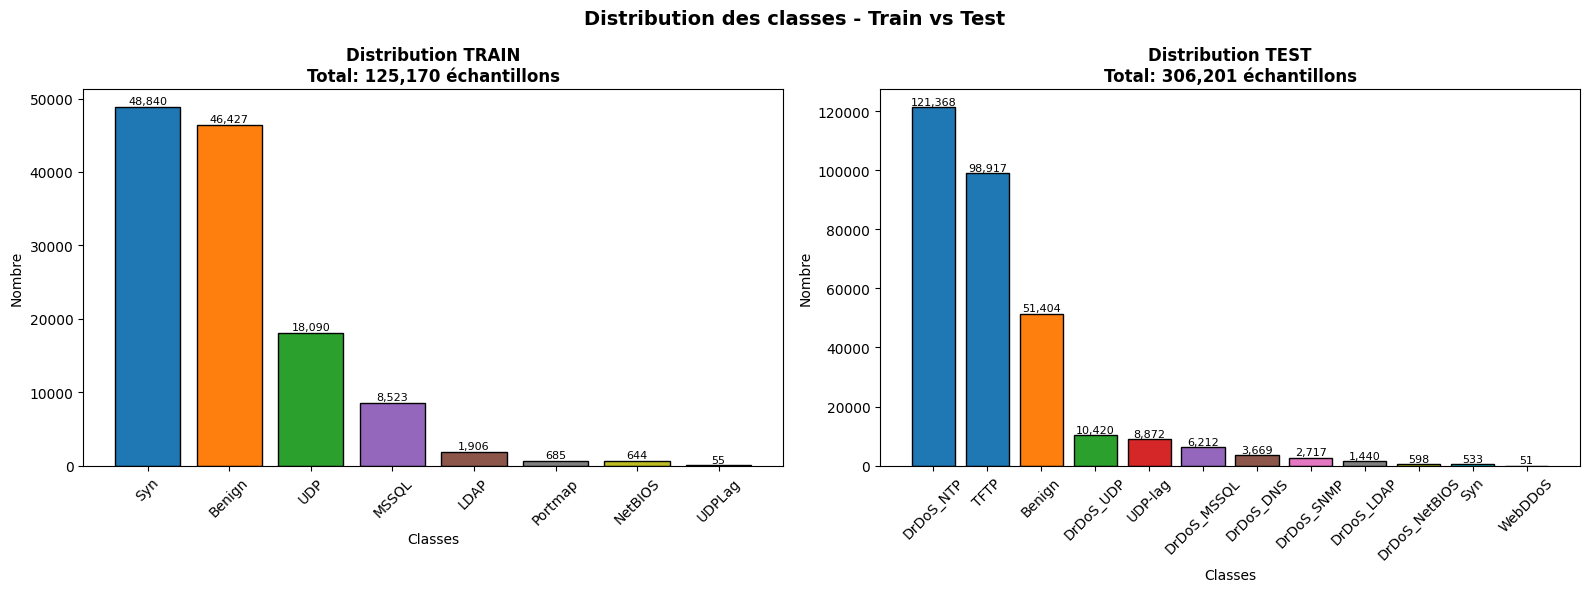

In [93]:
# 2. Créer les graphiques
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Train
train_counts = train_df['Label'].value_counts()
axes[0].bar(train_counts.index, train_counts.values, 
            color=plt.cm.tab10(np.linspace(0, 1, len(train_counts))),
            edgecolor='black')
axes[0].set_title(f'Distribution TRAIN\nTotal: {len(train_df):,} échantillons', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Classes', fontsize=10)
axes[0].set_ylabel('Nombre', fontsize=10)
axes[0].tick_params(axis='x', rotation=45)
for i, (label, count) in enumerate(train_counts.items()):
    axes[0].text(i, count + 100, f'{count:,}', ha='center', va='bottom', fontsize=8)

# Test
test_counts = test_df['Label'].value_counts()
axes[1].bar(test_counts.index, test_counts.values, 
            color=plt.cm.tab10(np.linspace(0, 1, len(test_counts))),
            edgecolor='black')
axes[1].set_title(f'Distribution TEST\nTotal: {len(test_df):,} échantillons', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Classes', fontsize=10)
axes[1].set_ylabel('Nombre', fontsize=10)
axes[1].tick_params(axis='x', rotation=45)
for i, (label, count) in enumerate(test_counts.items()):
    axes[1].text(i, count + 100, f'{count:,}', ha='center', va='bottom', fontsize=8)

plt.suptitle('Distribution des classes - Train vs Test', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [94]:
# taille de chaque fichier
train_df.shape, test_df.shape

((125170, 78), (306201, 78))

In [95]:
# appercu du fichier train
train_df.head()

,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Fwd Packets Length Total,Bwd Packets Length Total,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,17,1,2,0,530.0,0.0,265.0,265.0,265.0,0.0,...,8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Portmap
1,17,1,2,0,458.0,0.0,229.0,229.0,229.0,0.0,...,8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Portmap
2,17,2,2,0,458.0,0.0,229.0,229.0,229.0,0.0,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Portmap
3,17,1,2,0,422.0,0.0,211.0,211.0,211.0,0.0,...,8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Portmap
4,17,1,2,0,424.0,0.0,212.0,212.0,212.0,0.0,...,8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Portmap


In [96]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 125170 entries, 0 to 125169
Data columns (total 78 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Protocol                  125170 non-null  int64  
 1   Flow Duration             125170 non-null  int64  
 2   Total Fwd Packets         125170 non-null  int64  
 3   Total Backward Packets    125170 non-null  int64  
 4   Fwd Packets Length Total  125170 non-null  float64
 5   Bwd Packets Length Total  125170 non-null  float64
 6   Fwd Packet Length Max     125170 non-null  float64
 7   Fwd Packet Length Min     125170 non-null  float64
 8   Fwd Packet Length Mean    125170 non-null  float64
 9   Fwd Packet Length Std     125170 non-null  float64
 10  Bwd Packet Length Max     125170 non-null  float64
 11  Bwd Packet Length Min     125170 non-null  float64
 12  Bwd Packet Length Mean    125170 non-null  float64
 13  Bwd Packet Length Std     125170 non-null  float64
 14 

## Data Preprocessing

In [97]:
# Vérifier la distribution de la variable cible dans les données d'entraînement
train_df["Label"].value_counts()

Label
Syn        48840
Benign     46427
UDP        18090
MSSQL       8523
LDAP        1906
Portmap      685
NetBIOS      644
UDPLag        55
Name: count, dtype: int64

In [98]:
# Vérifier la distribution de la variable cible dans les données test
test_df["Label"].value_counts()

Label
DrDoS_NTP        121368
TFTP              98917
Benign            51404
DrDoS_UDP         10420
UDP-lag            8872
DrDoS_MSSQL        6212
DrDoS_DNS          3669
DrDoS_SNMP         2717
DrDoS_LDAP         1440
DrDoS_NetBIOS       598
Syn                 533
WebDDoS              51
Name: count, dtype: int64

Les valeurs de la colonne cible ne correspondent pas entre les données d'entraînement et de test. Nous allons harmoniser les étiquettes.

In [99]:
label_mapping = {
    'DrDoS_UDP': 'UDP',
    'DrDoS_MSSQL': 'MSSQL',
    'DrDoS_LDAP': 'LDAP',
    'DrDoS_NetBIOS': 'NetBIOS',
    'DrDoS_NTP': 'NTP',
    'DrDoS_SSDP': 'SSDP',
    'DrDoS_SNMP': 'SNMP',
    'DrDoS_DNS': 'DNS',
    'UDP-lag': 'UDPLag',
    'TFTP': 'TFTP',
    'Syn': 'Syn',
    'Portmap': 'Portmap',
    'BENIGN': 'BENIGN',
    'Benign': 'BENIGN'
}

train_df['Label'] = train_df['Label'].map(label_mapping).fillna(train_df['Label'])
test_df['Label'] = test_df['Label'].map(label_mapping).fillna(test_df['Label'])

# 2. Garder les classes communes
common_labels = set(train_df['Label'].unique()) & set(test_df['Label'].unique())
print(f"Classes communes : {common_labels}")

# 3. Filtrer
train_df = train_df[train_df['Label'].isin(common_labels)]
test_df = test_df[test_df['Label'].isin(common_labels)]


Classes communes : {'NetBIOS', 'Syn', 'LDAP', 'UDP', 'BENIGN', 'MSSQL', 'UDPLag'}


In [100]:
# # Vérifier la distribution de la variable cible dans les données de test apres mappage
test_df["Label"].value_counts()

Label
BENIGN     51404
UDP        10420
UDPLag      8872
MSSQL       6212
LDAP        1440
NetBIOS      598
Syn          533
Name: count, dtype: int64

In [101]:
# # Vérifier la distribution de la variable cible dans les données d'entraînement apres mappage
train_df["Label"].value_counts()

Label
Syn        48840
BENIGN     46427
UDP        18090
MSSQL       8523
LDAP        1906
NetBIOS      644
UDPLag        55
Name: count, dtype: int64

In [102]:
#Afficher les colonnes des données d'entraînement
train_df.columns

Index(['Protocol', 'Flow Duration', 'Total Fwd Packets',
       'Total Backward Packets', 'Fwd Packets Length Total',
       'Bwd Packets Length Total', 'Fwd Packet Length Max',
       'Fwd Packet Length Min', 'Fwd Packet Length Mean',
       'Fwd Packet Length Std', 'Bwd Packet Length Max',
       'Bwd Packet Length Min', 'Bwd Packet Length Mean',
       'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s',
       'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
       'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max',
       'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std',
       'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags',
       'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length',
       'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
       'Packet Length Min', 'Packet Length Max', 'Packet Length Mean',
       'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count',
       'SYN Flag Count', 'RST Fla

#  suppression des colonnes d'identification dans train et test

In [103]:
# suppression des colonnes d'identification dans train et test
cols_suppr = [
    "Flow ID",
    'Fwd Header Length.1',
    "Source IP",
    "Source Port",
    "Destination IP",
    "Destination Port",
    "Timestamp",
    "Unnamed: 0",
    "SimillarHTTP",           #  Colonnes d'identification
    "Inbound",                #  capturé de manière incohérente peut fausser le modele
         
]
train_df.drop(columns=cols_suppr, inplace=True, errors='ignore')
train_df = train_df.sample(frac=1, random_state=42).reset_index(drop=True)

test_df.drop(columns=cols_suppr, inplace=True, errors='ignore')
test_df = test_df.sample(frac=1, random_state=42).reset_index(drop=True)

# taille de chaque fichier apres suppression des colonnes d'identification dans train et test
train_df.shape, test_df.shape

((124485, 78), (79479, 78))

#### Identifier les colonnes catégorielles, les colonnes numériques et les colonnes catégorielles à haute cardinalité.

In [104]:
def grab_col_names(data, cat_th=10, car_th=20):

    # Categorical columns and categorical but high-cardinality columns
    cat_cols = [col for col in data.columns if data[col].dtypes == "O"]
    num_but_cat = [col for col in data.columns if data[col].nunique() < cat_th and data[col].dtypes != "O"]
    high_card_cat_cols = [col for col in data.columns if data[col].nunique() > car_th and data[col].dtypes == "O"]

    # Combine Object type columns and Low-unique-value numeric columns into cat_cols
    cat_cols = cat_cols + num_but_cat
    cat_cols = [col for col in cat_cols if col not in high_card_cat_cols]

    # Numerical columns excluding those considered as categorical
    num_cols = [col for col in data.columns if data[col].dtypes != "O"]
    num_cols = [col for col in num_cols if col not in num_but_cat]

    # Display information about the dataset
    print(f"Observations: {data.shape[0]}")
    print(f"Variables: {data.shape[1]}")
    print(f"Categorical Columns: {len(cat_cols)}")
    print(f"Numerical Columns: {len(num_cols)}")
    print(f"High Cardinality Categorical Columns: {len(high_card_cat_cols)}")
    print(f"Number but Categorical Columns: {len(num_but_cat)}")
    print("\n")

    return cat_cols, num_cols, high_card_cat_cols

cat_cols, num_cols, high_card_cat_cols = grab_col_names(train_df)
print(f"Catergorical Columns: {cat_cols}")
print(f"Numerical Columns: {num_cols}")
print(f"High Cardinality Categorical Columns: {high_card_cat_cols}")

Observations: 124485
Variables: 78
Categorical Columns: 20
Numerical Columns: 58
High Cardinality Categorical Columns: 0
Number but Categorical Columns: 20


Catergorical Columns: ['Protocol', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 'CWE Flag Count', 'ECE Flag Count', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate', 'Label']
Numerical Columns: ['Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Fwd Packets Length Total', 'Bwd Packets Length Total', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT To

In [105]:
# Afficher les valeurs uniques des colonnes catégorielles
for i in cat_cols:
    print(i, train_df[i].unique())

Protocol [ 6 17  0]
Fwd PSH Flags [0 1]
Bwd PSH Flags [0]
Fwd URG Flags [0]
Bwd URG Flags [0]
FIN Flag Count [0]
SYN Flag Count [0 1]
RST Flag Count [0 1]
PSH Flag Count [0]
ACK Flag Count [1 0]
URG Flag Count [0 1]
CWE Flag Count [0 1]
ECE Flag Count [0]
Fwd Avg Bytes/Bulk [0]
Fwd Avg Packets/Bulk [0]
Fwd Avg Bulk Rate [0]
Bwd Avg Bytes/Bulk [0]
Bwd Avg Packets/Bulk [0]
Bwd Avg Bulk Rate [0]
Label <StringArray>
['Syn', 'BENIGN', 'MSSQL', 'LDAP', 'UDP', 'NetBIOS', 'UDPLag']
Length: 7, dtype: str


In [106]:
# Afficher les colonnes avec une seule valeur unique
for i in train_df.columns:
    if train_df[i].nunique() == 1:
        print(i)

Bwd PSH Flags
Fwd URG Flags
Bwd URG Flags
FIN Flag Count
PSH Flag Count
ECE Flag Count
Fwd Avg Bytes/Bulk
Fwd Avg Packets/Bulk
Fwd Avg Bulk Rate
Bwd Avg Bytes/Bulk
Bwd Avg Packets/Bulk
Bwd Avg Bulk Rate


# valeurs infinie

In [107]:
# analyse des valeurs infinies
np.isinf(train_df.select_dtypes(include=np.number)).values.sum()

np.int64(0)

### valeurs manquantes

In [108]:
# Nombre total de valeurs manquantes
train_df.isnull().sum().sum()


np.int64(0)

### Lignes dupliquées

In [109]:
print(f" Nombre de lignes dupliquées : {train_df.duplicated().sum()}")

 Nombre de lignes dupliquées : 3494


In [110]:
# Supprimer les lignes dupliquées
train_df = train_df.drop_duplicates()

# Exploratory Data Analysis (EDA)


### Colonnes catégorielles


 Statistiques de Label :
Label
Syn        47246
BENIGN     45101
UDP        17795
MSSQL       8434
LDAP        1885
NetBIOS      475
UDPLag        55
Name: count, dtype: int64

Pourcentage :
Label
Syn        39.049185
BENIGN     37.276326
UDP        14.707706
MSSQL       6.970766
LDAP        1.557967
NetBIOS     0.392591
UDPLag      0.045458
Name: proportion, dtype: float64


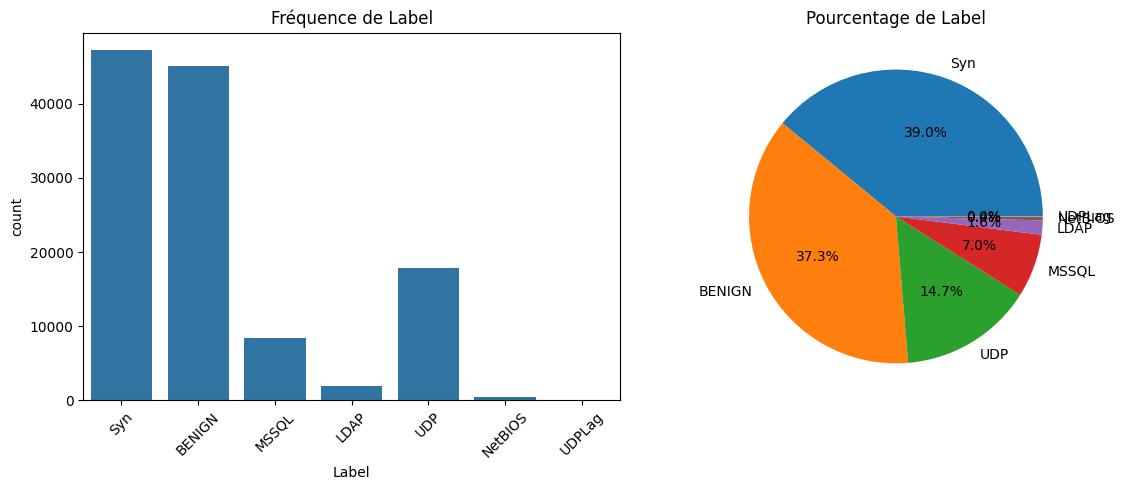

In [111]:
def analyser_colonne_cat(donnees, colonne):

    # Afficher les statistiques
    print(f"\n Statistiques de {colonne} :")
    print(donnees[colonne].value_counts())
    print("\nPourcentage :")
    print(donnees[colonne].value_counts(normalize=True) * 100)
    
    # Afficher les graphiques
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # Diagramme à barres
    sns.countplot(x=colonne, data=donnees, ax=axes[0])
    axes[0].set_title(f'Fréquence de {colonne}')
    axes[0].tick_params(axis='x', rotation=45)
    
    # Diagramme circulaire
    valeurs = donnees[colonne].value_counts()
    axes[1].pie(valeurs, labels=valeurs.index, autopct='%1.1f%%')
    axes[1].set_title(f'Pourcentage de {colonne}')
    
    plt.tight_layout()
    plt.show()

analyser_colonne_cat(train_df, 'Label')

# Analyser toutes les colonnes catégorielles
#for col in cat_cols:
    #analyser_colonne_cat(train_df, col)

# COLONNES NUMÉRIQUES

### Analyse de la taille des paquets et de la durée des flux

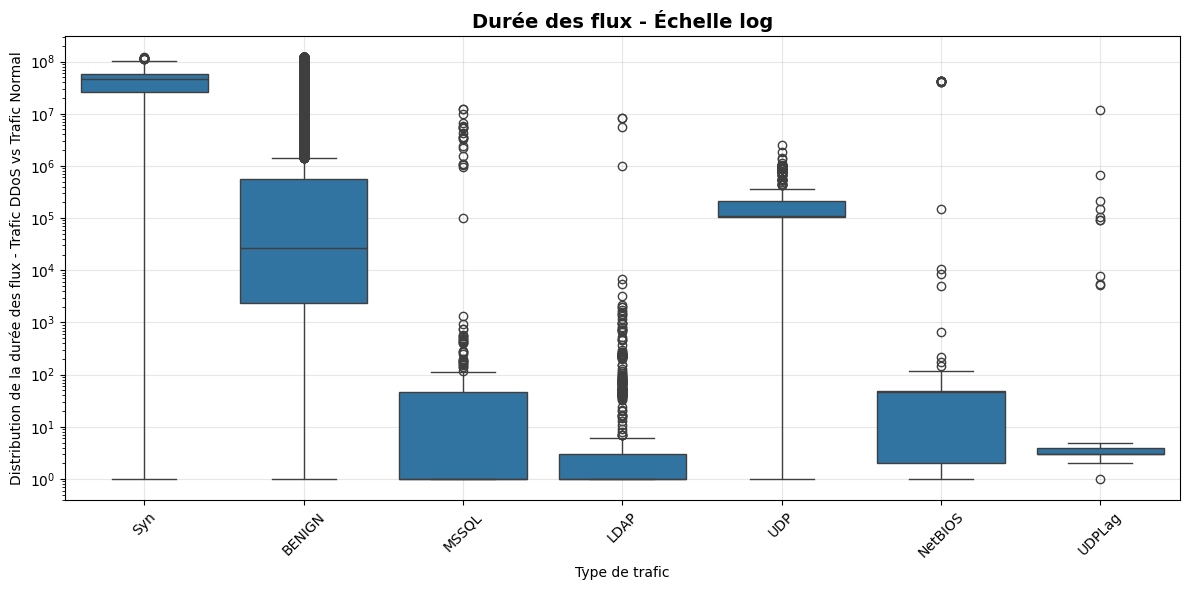

In [112]:
plt.figure(figsize=(12, 6))
sns.boxplot(x="Label", y="Flow Duration", data=train_df)
plt.yscale('log')  
plt.title("Durée des flux - Échelle log", fontsize=14, fontweight='bold')
plt.xlabel("Type de trafic")
plt.ylabel("Distribution de la durée des flux - Trafic DDoS vs Trafic Normal")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

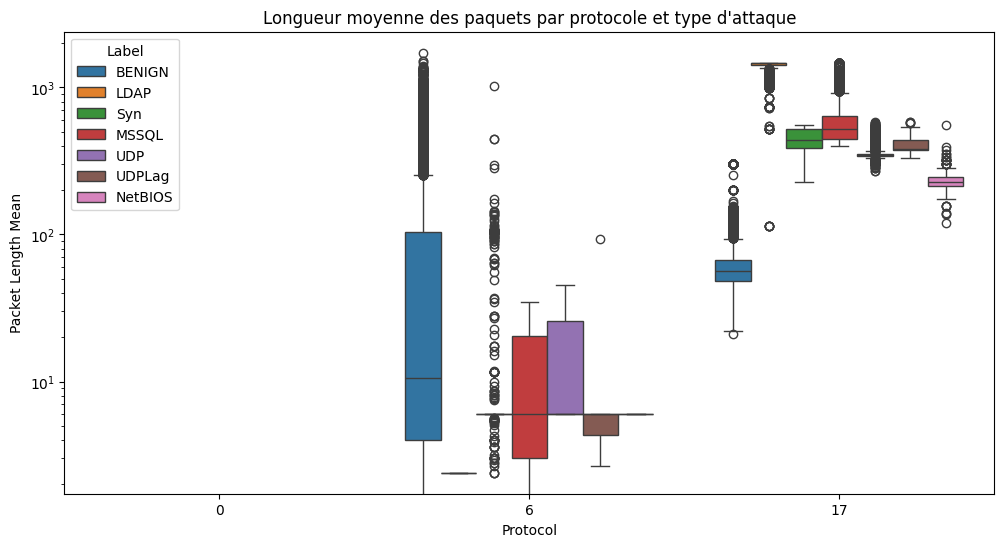

In [113]:
# Boxplot Longueur moyenne des paquets par protocole et type d'attaque
plt.figure(figsize=(12, 6))
sns.boxplot(x="Protocol", y="Packet Length Mean", hue="Label", data=train_df)
plt.yscale('log') 
plt.title("Longueur moyenne des paquets par protocole et type d'attaque")
plt.show()

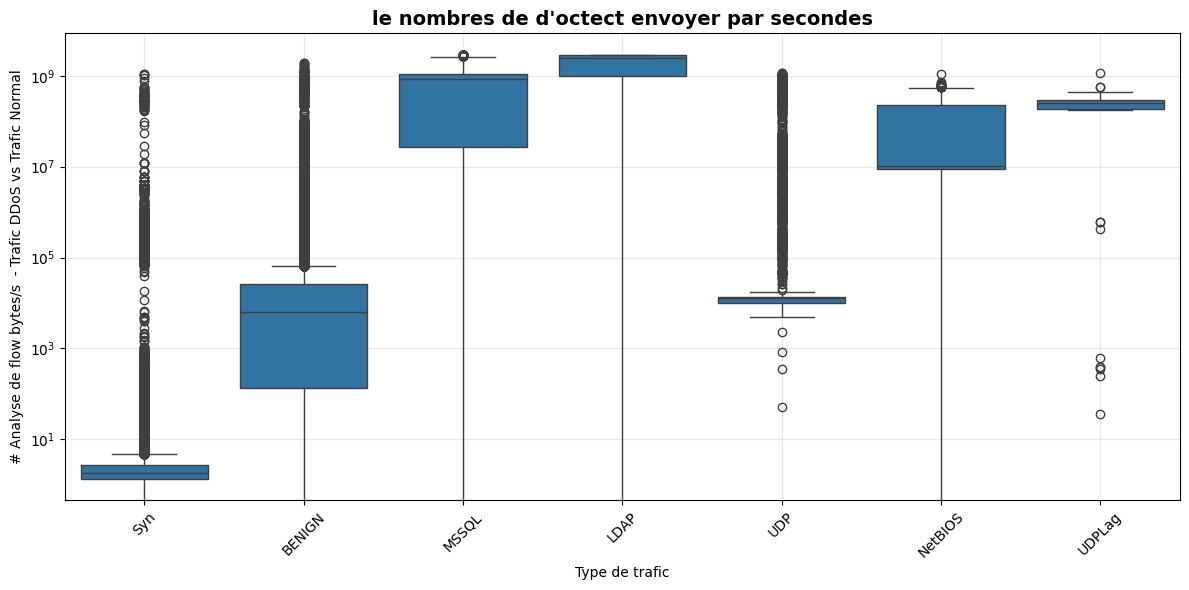

In [114]:
## Analyse de flow bytes/s dans les  classes
plt.figure(figsize=(12, 6))
sns.boxplot(x="Label", y="Flow Bytes/s", data=train_df)
plt.yscale('log')  
plt.title("le nombres de d'octect envoyer par secondes", fontsize=14, fontweight='bold')
plt.xlabel("Type de trafic")
plt.ylabel("# Analyse de flow bytes/s  - Trafic DDoS vs Trafic Normal")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Indicateurs de paquets et motifs d'attaque

MOYENNE DES FLAGS PAR TYPE D'ATTAQUE
         SYN Flag Count  ACK Flag Count
Label                                  
BENIGN         0.002062        0.226824
LDAP           0.000000        0.000531
MSSQL          0.000000        0.000119
NetBIOS        0.000000        0.004211
Syn            0.000169        0.994920
UDP            0.000000        0.000112
UDPLag         0.000000        0.109091


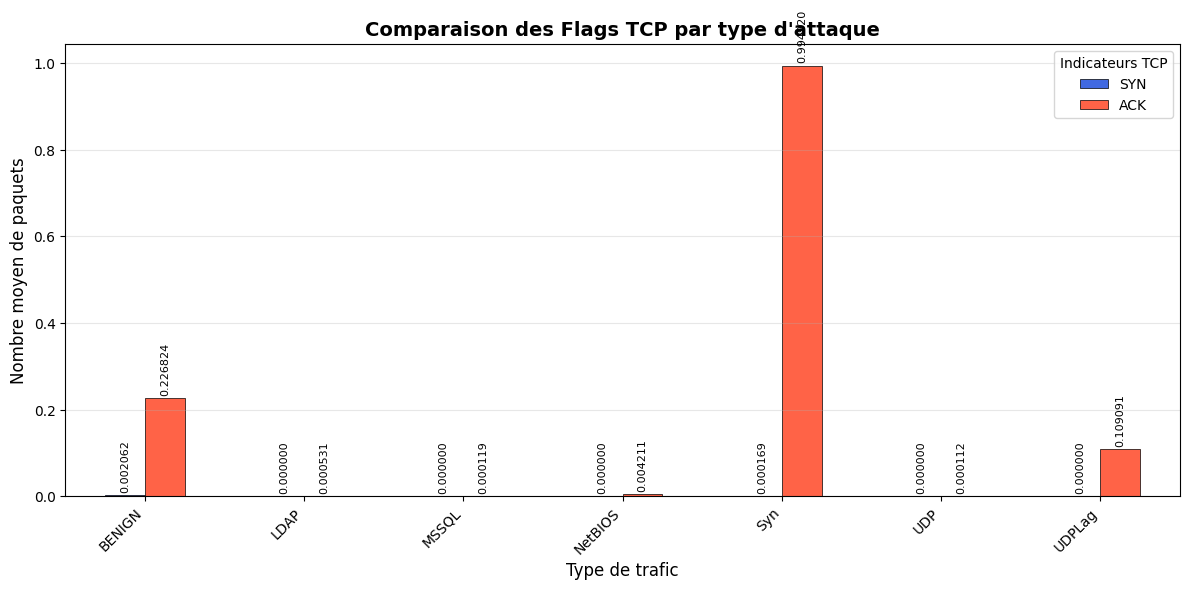

In [115]:
stats = train_df.groupby('Label')[['SYN Flag Count', 'ACK Flag Count']].mean()
print("="*50)
print("MOYENNE DES FLAGS PAR TYPE D'ATTAQUE")
print("="*50)
print(stats)

# Graphique
ax = stats.plot(kind='bar', figsize=(12, 6), color=['royalblue', 'tomato'], edgecolor='black', linewidth=0.5)

plt.title("Comparaison des Flags TCP par type d'attaque", fontsize=14, fontweight='bold')
plt.ylabel("Nombre moyen de paquets", fontsize=12)
plt.xlabel("Type de trafic", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title="Indicateurs TCP", labels=['SYN', 'ACK'])

for container in ax.containers:
    ax.bar_label(container, fmt='%.6f', fontsize=8, rotation=90, padding=2)

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Analyse des requêtes provenant de différents protocoles

Tableau croisé : Protocole vs Attaque
Protocol   0      6      17
Label                      
BENIGN    779  29374  14948
LDAP        2      1   1882
MSSQL       2      3   8429
NetBIOS     0      2    473
Syn        13  47162     71
UDP         0      3  17792
UDPLag      0      7     48


<Figure size 1200x600 with 0 Axes>

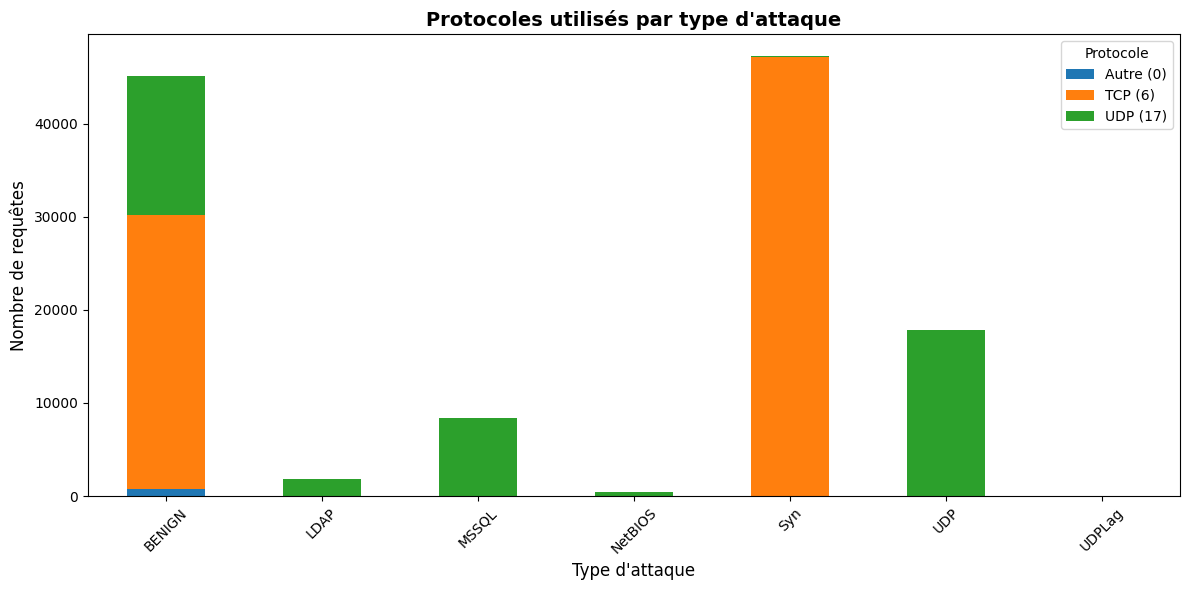


POURCENTAGES PAR PROTOCOLE ET ATTAQUE

LDAP:
  UDP (17): 1882 (99.8%)
  TCP (6) : 1 (0.1%)

MSSQL:
  UDP (17): 8429 (99.9%)
  TCP (6) : 3 (0.0%)

NetBIOS:
  UDP (17): 473 (99.6%)
  TCP (6) : 2 (0.4%)

Syn:
  UDP (17): 71 (0.2%)
  TCP (6) : 47162 (99.8%)

UDP:
  UDP (17): 17792 (100.0%)
  TCP (6) : 3 (0.0%)


In [116]:
# Créer un tableau 
tableau_croise = pd.crosstab(train_df['Label'], train_df['Protocol'])
print("Tableau croisé : Protocole vs Attaque")
print(tableau_croise)
plt.figure(figsize=(12, 6))

# Créer un graphique à barres 
tableau_croise.plot(kind='bar', stacked=True, figsize=(12, 6))

plt.title("Protocoles utilisés par type d'attaque", fontsize=14, fontweight='bold')
plt.xlabel("Type d'attaque", fontsize=12)
plt.ylabel("Nombre de requêtes", fontsize=12)
plt.xticks(rotation=45)
plt.legend(title="Protocole", labels=['Autre (0)', 'TCP (6)', 'UDP (17)'])
plt.tight_layout()
plt.show()


print("\n" + "="*50)
print("POURCENTAGES PAR PROTOCOLE ET ATTAQUE")
print("="*50)

for attaque in ['LDAP', 'MSSQL', 'NetBIOS', 'Syn', 'UDP']:
    total_attaque = train_df[train_df['Label'] == attaque].shape[0]
    udp = train_df[(train_df['Label'] == attaque) & (train_df['Protocol'] == 17)].shape[0]
    tcp = train_df[(train_df['Label'] == attaque) & (train_df['Protocol'] == 6)].shape[0]
    
    print(f"\n{attaque}:")
    print(f"  UDP (17): {udp} ({udp/total_attaque*100:.1f}%)")
    print(f"  TCP (6) : {tcp} ({tcp/total_attaque*100:.1f}%)")

### la matrice de corrélation

# 1. Définir les colonnes catégorielles
cat_columns = ['Protocol', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 
               'Bwd URG Flags', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count',
               'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 'CWE Flag Count', 
               'ECE Flag Count', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk',
               'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 
               'Bwd Avg Bulk Rate', 'Label']

# 2. Sélectionner les colonnes numériques → DataFrame
colonnes_num = [col for col in df_train.columns if col not in cat_columns]
df_num = df_train[colonnes_num]

# 3. Afficher la matrice de corrélation
plt.figure(figsize=(15, 12))
sns.heatmap(df_num.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title("Matrice de corrélation", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 4. Colonnes avec corrélation > 0.8
corr_matrix = df_num.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr = [col for col in upper.columns if any(upper[col] > 0.8)]

print(f"\nColonnes fortement corrélées (>0.8) : {len(high_corr)}")
print(high_corr)

# 5. Afficher les paires de corrélations fortes
print("\nPaires fortement corrélées :")
for col in high_corr:
    corr_pairs = upper[col][upper[col] > 0.8]
    for idx, val in corr_pairs.items():
        print(f"  {col} ↔ {idx} : {val:.3f}")

## Ingénierie des Caractéristiques

### Sélection des Caractéristiques

In [117]:
# Trouver les colonnes avec une seule valeur unique
colonnes_valeur_unique = [col for col in train_df.columns if train_df[col].nunique() == 1]
print(f"Colonnes avec une seule valeur : {colonnes_valeur_unique}")

Colonnes avec une seule valeur : ['Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'FIN Flag Count', 'PSH Flag Count', 'ECE Flag Count', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate']


In [118]:
#Supprimer les colonnes à valeur unique
train_df = train_df.drop(columns=colonnes_valeur_unique)
test_df = test_df.drop(columns=colonnes_valeur_unique)

In [119]:
# taille du jeu de données après suppression des colonnes à valeur unique
train_df.shape, test_df.shape

((120991, 66), (79479, 66))

In [120]:
#  Sélectionner uniquement les colonnes numériques
colonnes_numeriques = train_df.select_dtypes(include=[np.number])
# Calculer la matrice de corrélation
matrice_correlation = colonnes_numeriques.corr().abs()
# Créer un masque pour la partie supérieure de la matrice (corr(A,B) = corr(B,A))
masque = np.triu(np.ones(matrice_correlation.shape), k=1).astype(bool)

triangle_superieur = matrice_correlation.where(masque)
# Trouver les colonnes avec une corrélation >= 0.8
colonnes_fortement_correlees = [
    col for col in triangle_superieur.columns 
    if any(triangle_superieur[col] > 0.8)
]
# Afficher les résultats
print(f"Nombre total de colonnes fortement corrélées : {len(colonnes_fortement_correlees)}")
print("Colonnes fortement corrélées :", colonnes_fortement_correlees)

Nombre total de colonnes fortement corrélées : 34
Colonnes fortement corrélées : ['Bwd Packets Length Total', 'Fwd Packet Length Mean', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow IAT Std', 'Flow IAT Max', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Std', 'Bwd IAT Max', 'Fwd Packets/s', 'Packet Length Min', 'Packet Length Max', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'RST Flag Count', 'Avg Packet Size', 'Avg Fwd Segment Size', 'Avg Bwd Segment Size', 'Subflow Fwd Packets', 'Subflow Fwd Bytes', 'Subflow Bwd Packets', 'Subflow Bwd Bytes', 'Fwd Act Data Packets', 'Fwd Seg Size Min', 'Active Max', 'Active Min', 'Idle Mean', 'Idle Max', 'Idle Min']


In [121]:
# suppression des colonnes fortement corrélées dans train et test
train_df.drop(colonnes_fortement_correlees, axis=1, inplace=True)
test_df.drop(colonnes_fortement_correlees, axis=1, inplace=True)

In [122]:
# taille du jeu de données après suppression des colonnes fortement corrélées
train_df.shape, test_df.shape

((120991, 32), (79479, 32))

In [123]:
train_df.columns

Index(['Protocol', 'Flow Duration', 'Total Fwd Packets',
       'Total Backward Packets', 'Fwd Packets Length Total',
       'Fwd Packet Length Max', 'Fwd Packet Length Min',
       'Fwd Packet Length Std', 'Bwd Packet Length Max',
       'Bwd Packet Length Min', 'Flow Bytes/s', 'Flow Packets/s',
       'Flow IAT Mean', 'Flow IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean',
       'Bwd IAT Min', 'Fwd PSH Flags', 'Fwd Header Length',
       'Bwd Header Length', 'Bwd Packets/s', 'SYN Flag Count',
       'ACK Flag Count', 'URG Flag Count', 'CWE Flag Count', 'Down/Up Ratio',
       'Init Fwd Win Bytes', 'Init Bwd Win Bytes', 'Active Mean', 'Active Std',
       'Idle Std', 'Label'],
      dtype='str')

### Division en ensembles d'entraînement, validation et test

In [124]:
### Division de l'ensemble d'entraînement (80% train, 20% validation)
X_train, X_val, y_train, y_val = train_test_split(train_df.drop("Label", axis=1), train_df["Label"], test_size=0.2, random_state=42)

#Ensemble de tes
X_test, y_test = test_df.drop("Label", axis=1), test_df["Label"]

In [125]:
X_train.shape, X_val.shape, X_test.shape

((96792, 31), (24199, 31), (79479, 31))

In [126]:
y_train.shape, y_val.shape, y_test.shape

((96792,), (24199,), (79479,))

# Encodage de la variable cible

In [127]:
### Encodage de la variable cible
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_val = le.transform(y_val)
y_test = le.transform(y_test)

# mappage
label_map = {index: Label for index, Label in enumerate(le.classes_)}
label_map

{0: 'BENIGN',
 1: 'LDAP',
 2: 'MSSQL',
 3: 'NetBIOS',
 4: 'Syn',
 5: 'UDP',
 6: 'UDPLag'}

# Mise à l'échelle 

In [128]:
# Mise à l'échelle des caractéristiques en utilisant MinMaxScaler
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# gérer le déséquilibre des classes 

# Entraînement et évaluation des modèles

Entraînement des modèles:   0%|          | 0/5 [00:00<?, ?it/s]


Entraînement de Random Forest...


Entraînement des modèles:  20%|██        | 1/5 [00:52<03:30, 52.53s/it]


Entraînement de KNN...


Entraînement des modèles:  40%|████      | 2/5 [01:44<02:36, 52.16s/it]

...

Entraînement des modèles:  60%|██████    | 3/5 [02:47<01:54, 57.07s/it]


Entraînement de MLP...


Entraînement des modèles:  80%|████████  | 4/5 [09:15<03:07, 187.88s/it]


Entraînement de XGBoost...


Entraînement des modèles: 100%|██████████| 5/5 [10:07<00:00, 121.57s/it]


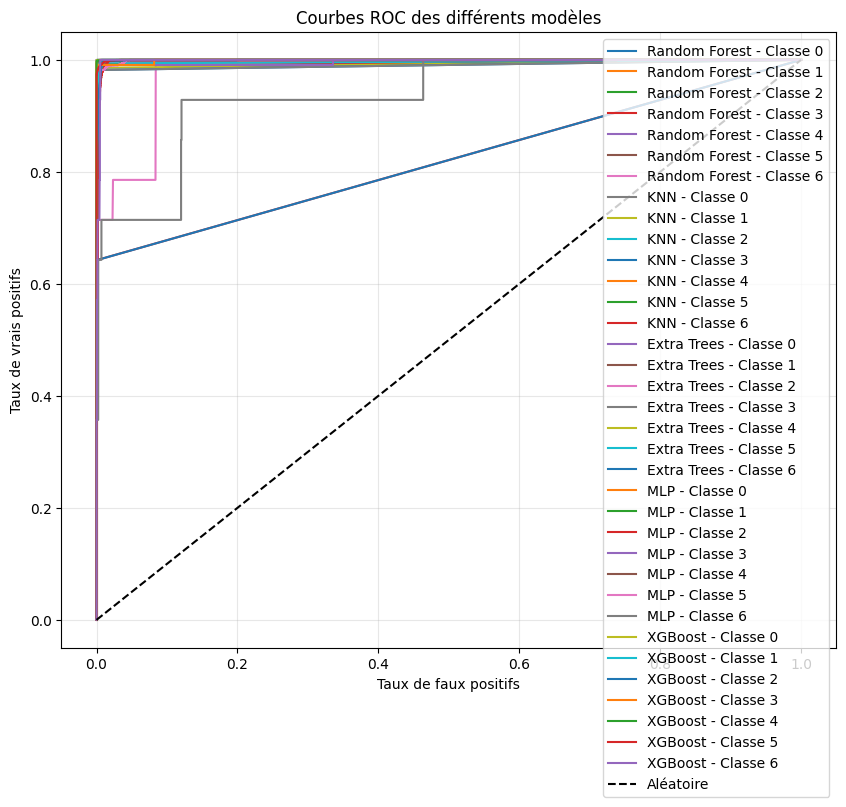


Comparaison des modèles


,Modèle,Accuracy,Precision,Recall,F1 Score,ROC AUC,CV Score
0,Random Forest,0.993306,0.993219,0.993306,0.993134,0.999850,0.993646
1,KNN,0.990165,0.990298,0.990165,0.990135,0.998929,0.990743
2,Extra Trees,0.992644,0.992439,0.992644,0.992497,0.998952,0.992944
3,MLP,0.988801,0.988641,0.988801,0.988628,0.999524,0.988894
4,XGBoost,0.992024,0.992068,0.992024,0.992017,0.999909,0.992603


In [129]:
# Fonction d'entraînement et d'évaluation
def train_model(X_train, X_test, y_train, y_test):
    # Initialisation des modèles
    modeles = {
        "Random Forest": RandomForestClassifier(random_state=42),
        "KNN": KNeighborsClassifier( n_neighbors=10),
        "Extra Trees": ExtraTreesClassifier( random_state=42),
        "MLP": MLPClassifier(hidden_layer_sizes=(100,),max_iter=1000,random_state=42),
        "XGBoost": XGBClassifier(random_state=42,eval_metric="mlogloss")
    }
    # Tableau des performances
    scores_list = []
    # Dictionnaires pour récupérer les résultats
    modeles_entraines = {}
    predictions = {}
    probabilites = {}

    # Figure ROC
    plt.figure(figsize=(10,8))

    # Nombre de classes
    nb_classes = len(np.unique(y_train))
    for nom, modele in tqdm(modeles.items(), desc="Entraînement des modèles"):
        print(f"\nEntraînement de {nom}...")
        # Entraînement
        modele.fit(X_train, y_train)
        # Prédictions
        y_pred = modele.predict(X_test)
        # Probabilités
        y_proba = modele.predict_proba(X_test)
        # Sauvegarder le modèle et ses résultats
        modeles_entraines[nom] = modele
        predictions[nom] = y_pred
        probabilites[nom] = y_proba
        # Calcul des métriques
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score( y_test, y_pred, average="weighted", zero_division=0)
        recall = recall_score(y_test,y_pred,average="weighted",zero_division=0)
        f1 = f1_score(y_test,y_pred,average="weighted",zero_division=0)
        roc_auc = roc_auc_score( y_test, y_proba, multi_class="ovr", average="weighted")
        # Validation croisée
        cv = np.mean(
            cross_val_score(modele,X_train,y_train,cv=5,n_jobs=-1)
        )
        # Courbes ROC
        for i in range(nb_classes):
            fpr, tpr, _ = roc_curve((y_test == i).astype(int),y_proba[:, i])
            plt.plot(fpr,tpr,label=f"{nom} - Classe {i}")
        # Sauvegarde des métriques
        scores_list.append({
            "Modèle": nom,
            "Accuracy": accuracy,
            "Precision": precision,
            "Recall": recall,
            "F1 Score": f1,
            "ROC AUC": roc_auc,
            "CV Score": cv
        })
 
    plt.plot( [0,1], [0,1], '--', color='black',label="Aléatoire")
    plt.xlabel("Taux de faux positifs")
    plt.ylabel("Taux de vrais positifs")
    plt.title("Courbes ROC des différents modèles")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()
    # Tableau des performances
    scores = pd.DataFrame(scores_list)
    return (
        scores,
        modeles_entraines,
        predictions,
        probabilites
    )
# Entraînement
scores, modeles, predictions, probabilites = train_model( X_train,X_val,y_train,y_val)
print("\nComparaison des modèles")
display(scores.style.background_gradient(cmap="viridis"))

# Afficher le graphique des scores de précision

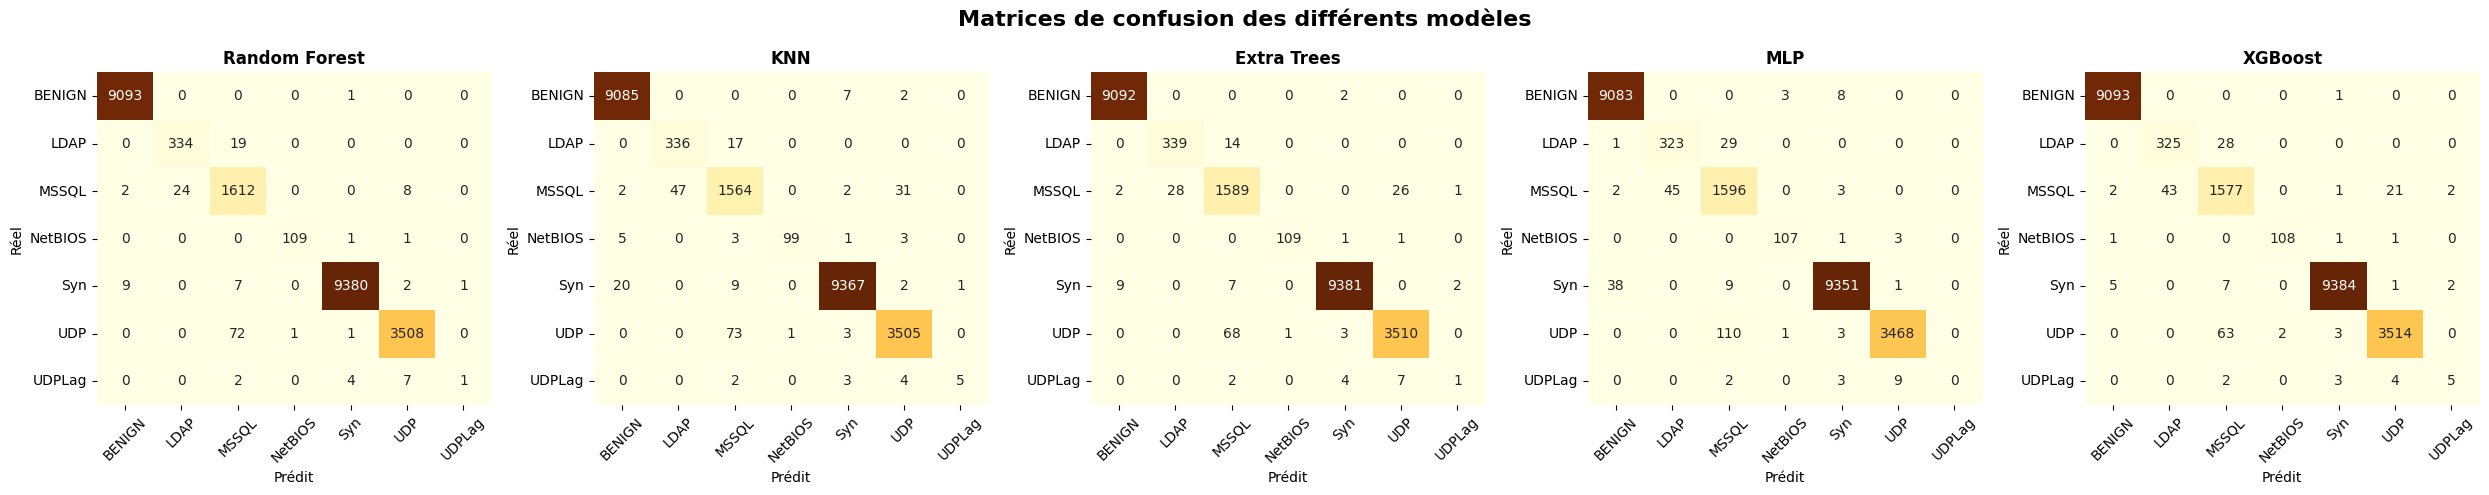

In [130]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
class_names = ['BENIGN', 'LDAP', 'MSSQL', 'NetBIOS', 'Syn', 'UDP', 'UDPLag']
# Création des sous-graphes (1 ligne × 5 colonnes)
fig, axes = plt.subplots(1, len(modeles), figsize=(25,5))

for ax, (nom, _) in zip(axes, modeles.items()):

    cm = confusion_matrix(y_val, predictions[nom])

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='YlOrBr',          # Palette beige → marron
        cbar=False,
        xticklabels=class_names,
        yticklabels=class_names,
        ax=ax
    )

    ax.set_title(nom, fontsize=12, fontweight='bold')
    ax.set_xlabel("Prédit")
    ax.set_ylabel("Réel")
    ax.tick_params(axis='x', rotation=45)
    ax.tick_params(axis='y', rotation=0)

plt.suptitle("Matrices de confusion des différents modèles", fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()

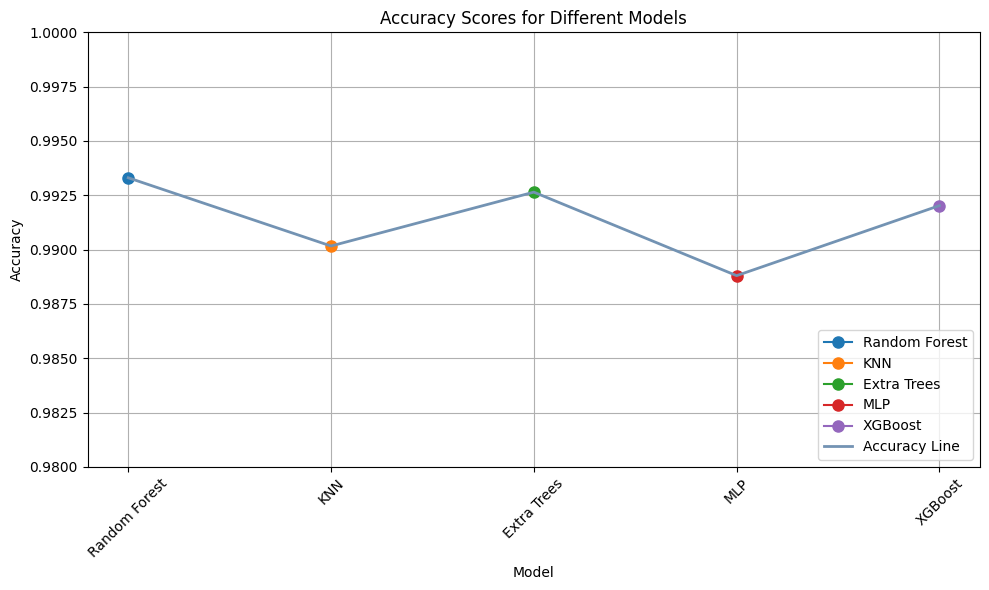

In [132]:
models = scores['Modèle']
accuracy = scores['Accuracy']
# Generate a color map
#colors = cm.viridis(np.linspace(0, 1, len(models)))

# Plotting the accuracy points with color for each model
plt.figure(figsize=(10, 6))
for i, (model, acc) in enumerate(zip(models, accuracy)):
    plt.plot(model, acc, marker='o',  markersize=8, label=model)

# Adding a line that passes through the points
plt.plot(models, accuracy, linestyle='-', color='#7393B3', linewidth=2, label="Accuracy Line")

# Customizing the plot
plt.title("Accuracy Scores for Different Models")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0.98, 1)  # Focus on 96%-100%
plt.xticks(rotation=45)
plt.grid(True)

# Display the plot with legend at the bottom right
handles, labels = plt.gca().get_legend_handles_labels()
unique_labels = dict(zip(labels, handles))  # Remove duplicate labels
plt.legend(unique_labels.values(), unique_labels.keys(), loc="lower right")

# Show the plot
plt.tight_layout()
plt.show()

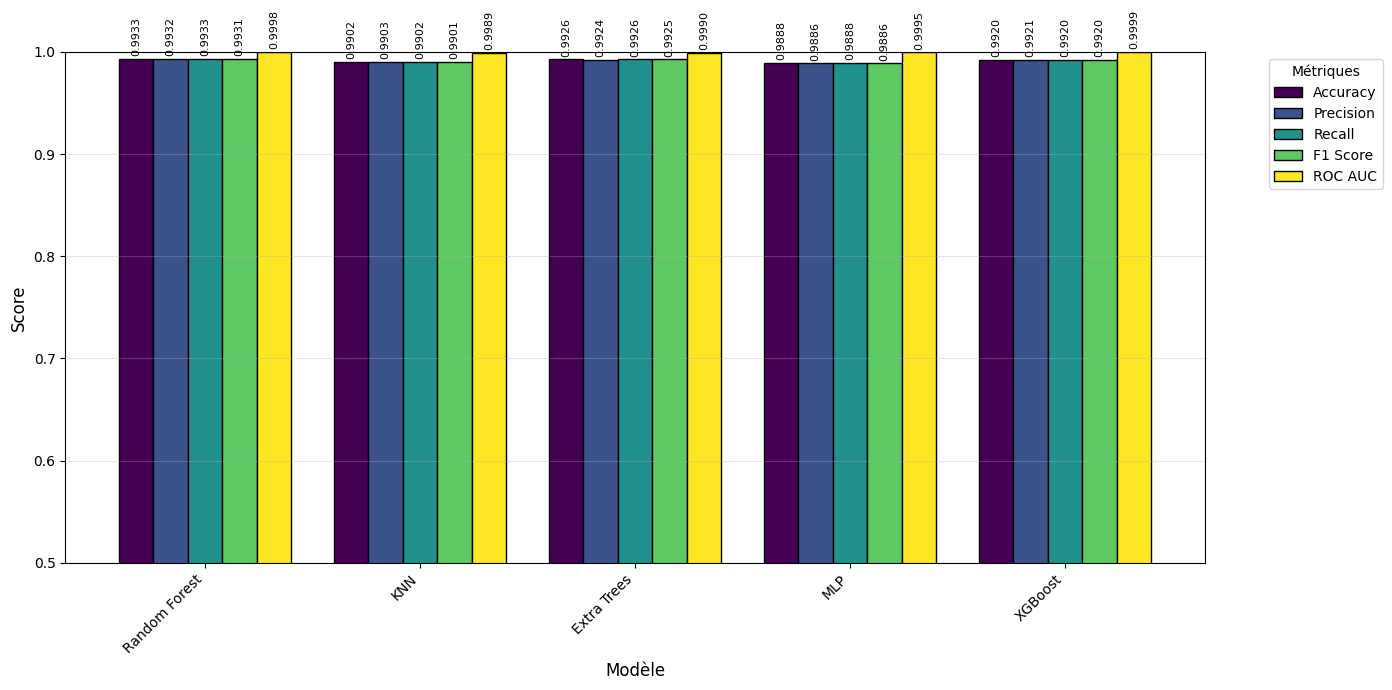

In [133]:
metriques = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC AUC']

# Préparer les données
df_plot = scores.set_index('Modèle')[metriques]

# Créer le graphique
fig, ax = plt.subplots(figsize=(14, 7))

# Barres groupées
df_plot.plot(kind='bar', ax=ax, colormap='viridis', edgecolor='black', linewidth=1, width=0.8)

# Ajouter les valeurs sur les barres
for container in ax.containers:
    ax.bar_label(container, fmt='%.4f', fontsize=8, rotation=90, padding=2)

#plt.title('Comparaison des 5 métriques des modèles', fontsize=14, fontweight='bold')
plt.xlabel('Modèle', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.ylim(0.5, 1.0)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Métriques', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# évaluation finale sur X_test avec le meilleur modèle


Performance sur le test :
  Accuracy  : 0.8738
  Precision : 0.8876
  Recall    : 0.8738
  F1-Score  : 0.8215
  ROC AUC   : 0.9372


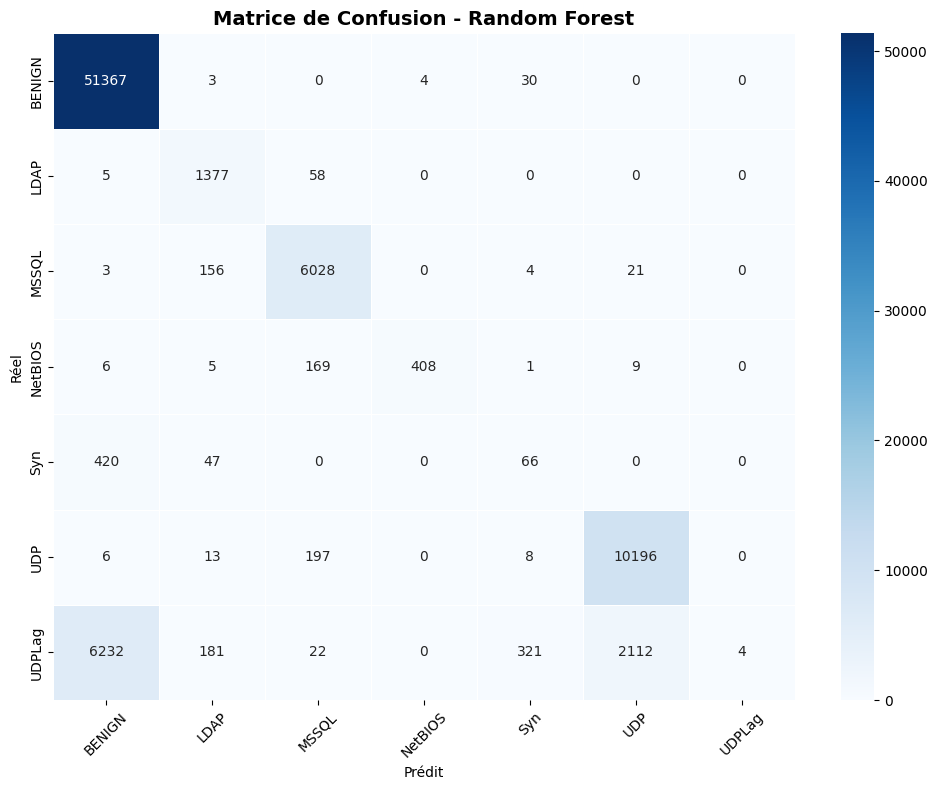


 Rapport de classification :
              precision    recall  f1-score   support

      BENIGN     0.8850    0.9993    0.9387     51404
        LDAP     0.7727    0.9563    0.8547      1440
       MSSQL     0.9311    0.9704    0.9503      6212
     NetBIOS     0.9903    0.6823    0.8079       598
         Syn     0.1535    0.1238    0.1371       533
         UDP     0.8264    0.9785    0.8960     10420
      UDPLag     1.0000    0.0005    0.0009      8872

    accuracy                         0.8738     79479
   macro avg     0.7941    0.6730    0.6551     79479
weighted avg     0.8876    0.8738    0.8215     79479



In [140]:
# 1. Trouver le meilleur modèle
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix)
meilleur_idx = scores['Accuracy'].idxmax()
meilleur_nom = scores.loc[meilleur_idx, 'Modèle']
meilleur_modele = modeles[meilleur_nom]

# 2. Prédictions sur le test
y_pred = meilleur_modele.predict(X_test)
y_proba = meilleur_modele.predict_proba(X_test)

# 3. Métriques sur le test
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted')
rec = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
roc = roc_auc_score(y_test, y_proba, multi_class='ovr', average='weighted')

print(f"\nPerformance sur le test :")
print(f"  Accuracy  : {acc:.4f}")
print(f"  Precision : {prec:.4f}")
print(f"  Recall    : {rec:.4f}")
print(f"  F1-Score  : {f1:.4f}")
print(f"  ROC AUC   : {roc:.4f}")

# 4. Matrice de confusion
class_names = ['BENIGN', 'LDAP', 'MSSQL', 'NetBIOS', 'Syn', 'UDP', 'UDPLag']
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, linewidths=0.5)
plt.title(f'Matrice de Confusion - {meilleur_nom}', fontsize=14, fontweight='bold')
plt.xlabel('Prédit'), plt.ylabel('Réel'), plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 5. Rapport de classification
print(f"\n Rapport de classification :")
print(classification_report(y_test, y_pred, target_names=class_names, digits=4))


# Exporter le meilleur modèle pour le déploiement

In [ ]:

# 7. Sauvegarder
import joblib
joblib.dump(meilleur_modele, 'meilleur_modele.pkl')
print(f"\n Modèle sauvegardé : meilleur_modele.pkl")